# Water Balance Modelling & Surface–Subsurface Flow
## A gentle introduction using pyCATHY

**References:**
- pyCATHY documentation: https://benjmy.github.io/pycathy_wrapper/
- Camporese et al. (2010), *Water Resources Research* — the original CATHY paper

---

> **How to use this notebook**  
> Cells marked 🔬 contain *runnable* pyCATHY code.  
> Cells marked 📐 contain equations and concept explanations.  
> Cells marked 💡 contain interactive widgets you can play with.  
> All concept cells can be read without running the code cells.

---

## Table of contents

1. [What is a water balance?](#1)
2. [From bucket model to physically-based model](#2)
3. [Inputs: what drives the model?](#3)
4. [The subsurface: Richards equation](#4)
5. [The surface: diffusion-wave equation](#5)
6. [Coupling surface and subsurface](#6)
7. [Soil hydraulic properties](#7)
8. [Numerical solvers](#8)
9. [Outputs: what does the model produce?](#9)
10. [pyCATHY workflow in practice](#10)
11. [A minimal working example](#11)
12. [Reading and visualising outputs](#12)

---
<a id='1'></a>
## 1 · What is a water balance?

### 📐 The fundamental equation

At its core, every hydrological model is an accounting system for water.  
Over any time period $\Delta t$ and any spatial domain:

$$
\underbrace{\Delta S}_{\text{change in storage}} =
\underbrace{P}_{\text{precipitation}} -
\underbrace{ET}_{\text{evapotranspiration}} -
\underbrace{Q}_{\text{runoff / streamflow}} -
\underbrace{D}_{\text{deep drainage}}
$$

| Term | Symbol | Description |
|---|---|---|
| Precipitation | $P$ | Rain + snowmelt arriving at the surface |
| Evapotranspiration | $ET$ | Water lost to the atmosphere from soil and plants |
| Runoff | $Q$ | Water leaving the catchment via streams |
| Deep drainage | $D$ | Water percolating below the root zone |
| Storage change | $\Delta S$ | Change in soil moisture + groundwater |

When $\Delta S = 0$ (long-term average), the catchment is in **steady state**: inputs exactly balance outputs.

### Key insight
The *partitioning* of precipitation into ET, runoff, and drainage is controlled by:
- Soil type and structure
- Topography
- Vegetation
- Antecedent soil moisture (how wet the soil already is)

Capturing this partitioning correctly — especially the role of the **unsaturated zone** — is the main challenge of hydrological modelling.

---
<a id='2'></a>
## 2 · From bucket model to physically-based model

### 📐 A spectrum of model complexity

Hydrological models exist on a spectrum between two extremes:

```
  Conceptual / empirical          Physically-based
  ──────────────────────────────────────────────────────────
  Simple bucket models     →     Richards + diffusion wave
  Few parameters           →     Many spatially distributed params
  Fast to run              →     Computationally intensive
  Calibrated to data       →     Grounded in physical laws
  Poor spatial detail      →     Full 3D spatial heterogeneity
```

**CATHY** (CATchment HYdrology) belongs to the **physically-based** family.  
It does not fit empirical parameters to observed runoff — it solves the governing partial differential equations of flow in porous media and on the land surface, given measurable soil and topographic properties.

### Why does this matter?

- **Extrapolation**: physical models can simulate conditions outside the calibration period (future climate, land use change)
- **Internal states**: you can inspect pressure head, saturation, and flow at every point in the 3D subsurface domain
- **Process understanding**: the model reveals *why* runoff occurs, not just *how much*

---
<a id='3'></a>
## 3 · Inputs: what drives the model?

### 📐 Atmospheric boundary conditions (`atmbc`)

CATHY is driven by a **net surface flux**, defined at each node of the surface mesh and at each time step:

$$
q_{\text{net}}(t) = P(t) - ET_p(t) \quad [\text{m s}^{-1}]
$$

where $ET_p$ is **potential** evapotranspiration (the atmospheric demand).  
The model then internally decides how much of that demand is actually met, depending on soil moisture — this is the **actual** ET ($ET_a \leq ET_p$).

| Input file | pyCATHY key | Description |
|---|---|---|
| `atmbc` | `update_atmbc()` | Time-varying surface flux (rain − ETp) |
| `soil` | `update_soil()` | Soil hydraulic parameters per layer/zone |
| `ic` | `update_ic()` | Initial pressure head distribution |
| `parm` | `update_parm()` | Solver settings (time stepping, output frequency) |
| `nansfdirbc` / `nansfdirbc` | `update_nansfdirbc()` | No-flow or fixed-head lateral boundaries |

### 💡 Sign convention
In CATHY, **positive** flux = water entering the domain (rain).  
**Negative** flux = water leaving (evaporation from soil, transpiration from roots).

```
  ↓ P  (positive)     ↑ ET  (negative)
  ════════════════════════  ← land surface
       subsurface domain
```

---
<a id='4'></a>
## 4 · The subsurface: Richards equation

### 📐 Governing equation

Flow in the variably-saturated subsurface (from the dry surface soil all the way down to the saturated aquifer) is described by the **Richards equation**:

$$
S_w S_s \frac{\partial \psi}{\partial t}
+ \Phi \frac{\partial S_w}{\partial t}
= \nabla \cdot \left[ K_s K_r(\psi) \left( \nabla \psi + n_z \right) \right]
+ q_{ss}
$$

| Symbol | Name | Unit |
|---|---|---|
| $\psi$ | Pressure head (matric potential) | m |
| $S_w$ | Degree of saturation ($0 \leq S_w \leq 1$) | − |
| $S_s$ | Specific storage | m⁻¹ |
| $\Phi$ | Porosity | − |
| $K_s$ | Saturated hydraulic conductivity | m s⁻¹ |
| $K_r(\psi)$ | Relative hydraulic conductivity | − |
| $n_z$ | Unit vector pointing upward | − |
| $q_{ss}$ | Sink/source term (e.g. root water uptake) | s⁻¹ |

### 📐 Physical interpretation

- **Left side** = rate of change of water stored in the soil (compressible solid skeleton + changes in saturation)
- **Right side** = net flux divergence (how much more water flows in than out, per unit volume) + sources/sinks

The key nonlinearity is $K_r(\psi)$: hydraulic conductivity drops by **orders of magnitude** as soil dries out.  
This makes the equation highly nonlinear and requires iterative solvers.

### 📐 Pressure head $\psi$ as the primary variable

```
  ψ > 0   →   saturated zone (positive pore water pressure)
  ψ = 0   →   water table (phreatic surface)
  ψ < 0   →   unsaturated zone (capillary suction, matric potential)
  ψ → −∞  →   very dry soil
```

CATHY solves for $\psi$ everywhere in the 3D mesh at every time step.

---
<a id='5'></a>
## 5 · The surface: diffusion-wave equation

### 📐 Governing equation

Once water reaches the surface (either by direct rainfall excess or by **exfiltration** from a saturated subsurface), it flows downslope as overland flow.  
CATHY uses the **diffusion-wave approximation** of the Saint-Venant equations:

$$
\frac{\partial Q}{\partial t}
+ c_k \frac{\partial Q}{\partial s}
= D_h \frac{\partial^2 Q}{\partial s^2}
+ c_k q_s
$$

| Symbol | Name |
|---|---|
| $Q$ | Discharge along a surface flow path (m³ s⁻¹) |
| $s$ | Distance along the flow path (m) |
| $c_k$ | Kinematic wave celerity (m s⁻¹) |
| $D_h$ | Hydraulic diffusivity (m² s⁻¹) |
| $q_s$ | Lateral inflow from rain or exfiltration (m² s⁻¹) |

### 📐 Flow path routing

CATHY identifies the surface flow network **automatically** from the DEM using path-based routing:
- Each surface node drains to its steepest downslope neighbour
- This creates a **channel network** used by the diffusion-wave solver

```
  DEM → slope → flow direction → flow accumulation → channel network
               (steepest descent)                    (diffusion wave)
```

---
<a id='6'></a>
## 6 · Coupling surface and subsurface

### 📐 How the two equations talk to each other

The surface and subsurface domains are coupled through **boundary conditions** at the land surface.  
At each surface node and at each time step, CATHY evaluates a switching condition:

```
  ┌─────────────────────────────────────────────────────────────────┐
  │                   SURFACE NODE STATE MACHINE                    │
  │                                                                 │
  │  Unsaturated & q_net < infiltration capacity                    │
  │    → all rain infiltrates  (Neumann BC: flux prescribed)        │
  │                       │                                         │
  │                       ▼ soil fills up (ψ → 0)                   │
  │  Saturated OR q_net > infiltration capacity                     │
  │    → ponding begins  (Dirichlet BC: ψ = pond depth)             │
  │    → excess → overland flow → routed by diffusion wave          │
  └─────────────────────────────────────────────────────────────────┘
```

This **Boundary Condition (BC) switching** approach — rather than a simpler infiltration-excess formula — is what makes CATHY physically rigorous. It can simulate:

- **Infiltration-excess** (Hortonian) runoff: rain rate > soil infiltration capacity
- **Saturation-excess** (Dunne) runoff: soil fills from below, water table reaches surface
- **Return flow** (exfiltration): subsurface water seeps back out to the surface

All three mechanisms can occur simultaneously at different parts of the catchment.

---
<a id='7'></a>
## 7 · Soil hydraulic properties

### 📐 van Genuchten relationships

The nonlinear functions $K_r(\psi)$ and $S_w(\psi)$ are specified by a **soil retention model**.  
CATHY supports several; the most widely used is **van Genuchten (1980)**:

**Saturation–pressure relationship:**
$$
S_e(\psi) = \frac{S_w - S_{wr}}{S_{ws} - S_{wr}} =
\begin{cases}
\left[1 + |\alpha \psi|^n\right]^{-m} & \psi < 0 \\
1 & \psi \geq 0
\end{cases}
$$

**Relative permeability:**
$$
K_r(S_e) = S_e^{1/2} \left[ 1 - \left(1 - S_e^{1/m}\right)^m \right]^2
$$

| Parameter | pyCATHY name | Typical range | Meaning |
|---|---|---|---|
| $\alpha$ | `VGRMCA` | 1–10 m⁻¹ | Inverse of air-entry pressure |
| $n$ | `VGRN` | 1.1–3 | Pore size distribution index |
| $m$ | (derived) | $1 - 1/n$ | Shape parameter |
| $S_{wr}$ | `VGRMC` | 0.02–0.15 | Residual water saturation |
| $S_{ws}$ | `VGPSAT` | ≈ 1 | Saturated water saturation |
| $K_s$ | `PERMX/Y/Z` | 10⁻⁸–10⁻⁴ m/s | Saturated hydraulic conductivity |

### 💡 Key insight: why nonlinearity matters

A sandy soil goes from nearly impermeable when dry to highly conductive when wet — a change of 4–6 orders of magnitude in $K_r$.  
This extreme nonlinearity is why rainfall events of the same intensity can produce very different runoff responses depending on antecedent soil moisture.

In [1]:
# 💡 Interactive: explore van Genuchten curves
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Layout
from IPython.display import display, clear_output

try:
    %matplotlib widget
except Exception:
    %matplotlib inline

def van_genuchten(psi_range, alpha, n, Swr=0.05):
    """Return Se(psi) and Kr(Se) for given vG parameters."""
    m  = 1 - 1/n
    Se = np.where(psi_range < 0,
                  (1 + (alpha * np.abs(psi_range))**n)**(-m),
                  1.0)
    Sw = Swr + Se * (1 - Swr)
    Kr = np.where(Se > 0,
                  Se**0.5 * (1 - (1 - Se**(1/m))**m)**2,
                  0.0)
    return Sw, Kr

psi = np.linspace(-10, 0.1, 500)

# Widgets
w_alpha = widgets.FloatSlider(value=2.0, min=0.1, max=15.0, step=0.1,
                               description='α (m⁻¹):', style={'description_width':'80px'},
                               layout=Layout(width='400px'))
w_n     = widgets.FloatSlider(value=1.5, min=1.05, max=4.0, step=0.05,
                               description='n:',       style={'description_width':'80px'},
                               layout=Layout(width='400px'))
w_swr   = widgets.FloatSlider(value=0.05, min=0.0, max=0.3, step=0.01,
                               description='Swr:',     style={'description_width':'80px'},
                               layout=Layout(width='400px'))

# Preset soil type buttons
PRESETS = {
    'Sand':       dict(alpha=14.5, n=2.68, Swr=0.045),
    'Loam':       dict(alpha=3.6,  n=1.56, Swr=0.078),
    'Clay loam':  dict(alpha=1.9,  n=1.31, Swr=0.095),
    'Clay':       dict(alpha=0.8,  n=1.09, Swr=0.068),
}

preset_btns = [widgets.Button(description=k, layout=Layout(width='100px'))
               for k in PRESETS]

fig_out = widgets.Output()

def redraw(_=None):
    Sw, Kr = van_genuchten(psi, w_alpha.value, w_n.value, w_swr.value)
    with fig_out:
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.plot(psi, Sw, lw=2, color='#0072B2')
        ax1.set_xlabel('Pressure head ψ (m)')
        ax1.set_ylabel('Degree of saturation Sw (−)')
        ax1.set_title('Retention curve')
        ax1.axvline(0, color='grey', linestyle='--', lw=0.8)
        ax1.set_ylim(0, 1.05)
        ax1.grid(True, linestyle='--', alpha=0.4)
        ax1.text(-9, 0.92, f'α={w_alpha.value:.1f}, n={w_n.value:.2f}, Swr={w_swr.value:.2f}',
                 fontsize=9, color='#333')

        ax2.semilogy(psi, np.clip(Kr, 1e-8, 1), lw=2, color='#D55E00')
        ax2.set_xlabel('Pressure head ψ (m)')
        ax2.set_ylabel('Relative hydraulic conductivity Kr (−)')
        ax2.set_title('Conductivity curve')
        ax2.axvline(0, color='grey', linestyle='--', lw=0.8)
        ax2.grid(True, which='both', linestyle='--', alpha=0.4)

        plt.tight_layout()
        plt.show()

def make_preset_handler(name):
    def handler(b):
        p = PRESETS[name]
        w_alpha.value, w_n.value, w_swr.value = p['alpha'], p['n'], p['Swr']
    return handler

for btn, name in zip(preset_btns, PRESETS):
    btn.on_click(make_preset_handler(name))

for w in [w_alpha, w_n, w_swr]:
    w.observe(redraw, names='value')

display(
    VBox([
        widgets.HTML('<b>💡 Van Genuchten curves — adjust parameters or pick a soil type</b>'),
        HBox(preset_btns),
        w_alpha, w_n, w_swr,
        fig_out
    ])
)
redraw()

---
<a id='8'></a>
## 8 · Numerical solvers

### 📐 Discretisation strategy

```
  Domain                 Method          Grid
  ─────────────────────────────────────────────────────────
  Subsurface (3D)   →   Galerkin FEM   →   Tetrahedral mesh
  Surface (1D/2D)   →   Finite diff    →   Flow-path network from DEM
  Time              →   Weighted FD    →   Adaptive time stepping
```

### 📐 Time stepping

CATHY uses **adaptive** time stepping controlled by three parameters:

| Parameter | pyCATHY key | Meaning |
|---|---|---|
| `DTMIN` | solver min time step | Smallest allowed Δt (s) — prevents infinite loop |
| `DTMAX` | solver max time step | Largest allowed Δt (s) — controls accuracy |
| `DELTAT` | initial time step | Starting Δt (s) |

The solver **shrinks** Δt when Newton/Picard iteration fails to converge (steep wetting fronts, rapid saturation changes), and **expands** Δt during smooth, quasi-steady periods.

### 📐 Linearisation

Because $K_r(\psi)$ and $S_w(\psi)$ are nonlinear, the Richards equation must be linearised at each time step.  
CATHY supports:
- **Picard iteration** — simple, robust, slower convergence
- **Newton iteration** — faster convergence but can diverge for very dry soils

The `TRAFLAG` parameter selects between them (`TRAFLAG=0` → Picard).

### 📐 Mesh and the preprocessor

Before the solver runs, CATHY's **preprocessor** (`run_preprocessor`) takes the DEM and:
1. Extracts surface drainage directions and channel network
2. Creates a 3D tetrahedral mesh by **extruding** the surface mesh vertically
3. Assigns soil zones and boundary conditions to each element/node

```
  DEM (raster)  ──preprocess──►  3D mesh  ──processor──►  ψ(x,y,z,t), Q(s,t)
```

---
<a id='9'></a>
## 9 · Outputs: what does the model produce?

### 📐 Primary outputs

| Output | File | pyCATHY reader | Description |
|---|---|---|---|
| Pressure head | `psi` | `read_outputs('psi')` | $\psi(x,y,z,t)$ — full 3D, all nodes |
| Degree of saturation | `sw` | `read_outputs('sw')` | $S_w(x,y,z,t)$ — volumetric water content proxy |
| Actual ET | `ET` | `read_outputs('ET')` | $ET_a(x,y,t)$ — spatially distributed |
| Streamflow | `hgraph` | `read_outputs('hgraph')` | $Q(t)$ at the catchment outlet |
| Water table depth | `wt` | derived from $\psi=0$ surface | Depth to saturation |

### 📐 Derived diagnostics

From $\psi$ and $S_w$ you can compute:

- **Water table depth** = depth where $\psi = 0$ at each (x,y) column
- **Soil moisture deficit** = how much water the unsaturated zone can still absorb
- **Groundwater contribution to streamflow** = fraction of $Q$ that exfiltrated from the saturated zone
- **Vadose zone storage** = $\int_{z_{wt}}^{z_{surf}} \Phi S_w \, dz$

### 📐 Output frequency

Controlled by `TIMPRTi` — a list of simulation times (in seconds) at which output is written.  
Setting `TIMPRTi = t_atmbc` (every atmospheric forcing time step) gives daily snapshots for ERA5-driven simulations.

| `IPRT` value | Output detail |
|---|---|
| 1 | Minimal — outlet hydrograph only |
| 2 | + pressure head and saturation at `TIMPRTi` times |
| 3 | + boundary fluxes |
| 4 | + ET partition (actual vs potential) |

---
<a id='10'></a>
## 10 · pyCATHY workflow in practice

### 📐 The five-step workflow

```
  ┌──────────────────────────────────────────────────────────────┐
  │  1. CREATE project                                           │
  │     simu = CATHY(dirName='path/', prj_name='myrun')         │
  │                                                              │
  │  2. SET UP inputs                                            │
  │     simu.update_prepo_inputs(DEM=..., delta_x=5, delta_y=5) │
  │     simu.update_soil(PERMX=1e-5, ...)                        │
  │     simu.update_ic(pressure_head_ini=-1.0)                   │
  │     simu.update_atmbc(time=..., netValue=...)                │
  │     simu.update_parm(IPRT=2, TIMPRTi=...)                    │
  │                                                              │
  │  3. RUN preprocessor  (mesh generation)                     │
  │     simu.run_preprocessor()                                  │
  │                                                              │
  │  4. RUN processor  (PDE solver)                             │
  │     simu.run_processor(DTMIN=1e-2, DTMAX=1e4)               │
  │                                                              │
  │  5. READ & PLOT outputs                                     │
  │     df_psi = simu.read_outputs('psi')                       │
  │     simu.show(prop='sw')                                     │
  └──────────────────────────────────────────────────────────────┘
```

### 📐 pyCATHY object model

The `CATHY` class is the central object — it manages all file I/O, calls the CATHY binary, and provides readers and plotters:

```python
from pyCATHY import cathy_tools

simu = cathy_tools.CATHY(
    dirName  = './SSHydro/',   # where project files are written
    prj_name = 'tutorial'      # subfolder name
)
```

After this, `simu.workdir` points to `./SSHydro/tutorial/` — all CATHY input/output files live there.

📖 Full API: https://benjmy.github.io/pycathy_wrapper/content/api/generated/cathy_tools.html

---
<a id='11'></a>
## 11 · A minimal working example

The classic benchmark for surface–subsurface coupling is the **Weill et al. (2009)** hillslope:  
a sloped rectangular catchment with a stream at the bottom, uniform soil, and a synthetic rain-then-dry forcing.

> **DEM note:** CATHY requires a DEM with **exactly one outlet** (a single global minimum).  
> A purely y-sloped rectangle would leave the entire bottom row at the same elevation — multiple co-equal minima — which breaks the flow-routing step.  
> We therefore add a small cross-slope in x so all flow converges to the single corner node at (x=0, y=0).

See also: https://benjmy.github.io/pycathy_wrapper/content/SSHydro/plot_1_pyCATHY_weilletal.html

In [2]:
# 🔬 Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from pyCATHY import cathy_tools
from pyCATHY.plotters import cathy_plots as cplt

print('✓ pyCATHY imported')

✓ pyCATHY imported


In [3]:
# 🔬 Step 1 — Create project
simu = cathy_tools.CATHY(
    dirName  = './tutorial_output/',
    prj_name = 'weill_hillslope'
)
print(f'Project folder: {simu.workdir}')

🏁 Initiate CATHY object

Project folder: /home/z0272571a@campus.csic.es/Nextcloud/BenCSIC/Codes/Tech4agro_org/GRwater_CATmentHYdrology/notebooks/./tutorial_output/


Global minimum (outlet): row=19, col=0, z=1.050 m  → node at (x=0.0, y=19.0)
Second minimum          : z=1.070 m  (gap = 0.020 m  → unambiguous single outlet ✓)


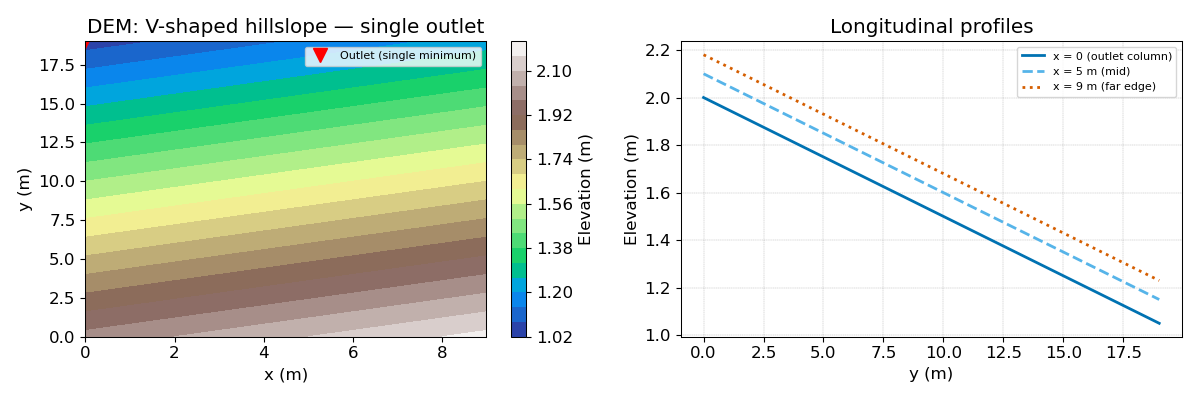

In [4]:
# 🔬 Step 2a — Build DEM: V-shaped hillslope with a single outlet
#
# ⚠️  IMPORTANT — CATHY requires exactly ONE outlet node (the global minimum).
#    A flat-bottomed rectangular DEM with a uniform slope along y would place
#    the entire bottom row at the same elevation → multiple co-equal minima →
#    the preprocessor's flow-routing algorithm fails or produces an ambiguous
#    drainage network.
#
# Fix: add a gentle CROSS-SLOPE in the x-direction so all flow converges to
# a single corner node (x=0, y=0).  The DEM is the sum of two gradients:
#
#   z(x, y) = z_base
#            + slope_y  * (Y_max - y)   ← main slope (upslope → outlet)
#            + slope_x  * x             ← lateral tilt (right → left)
#
# This gives a planar hillslope draining to the single corner (x=0, y=0).

nx, ny    = 10, 20     # surface nodes in x and y
dx, dy    = 1.0, 1.0   # grid spacing (m)
slope_y   = 0.05       # 5 % main slope toward y = 0
slope_x   = 0.02       # 2 % cross-slope toward x = 0
z_base    = 1.0        # elevation at the single outlet corner (m)

x  = np.arange(nx) * dx
y  = np.arange(ny) * dy
XX, YY = np.meshgrid(x, y)   # shape (ny, nx) — rows = y, cols = x

DEM = z_base + slope_y * (ny * dy - YY) + slope_x * XX
#              ─────────────────────────   ──────────────
#              rises away from y=0         rises away from x=0
#              (main downslope direction)   (lateral convergence)

outlet_row, outlet_col = np.unravel_index(DEM.argmin(), DEM.shape)
print(f'Global minimum (outlet): row={outlet_row}, col={outlet_col},'
      f' z={DEM.min():.3f} m  → node at (x={x[outlet_col]:.1f}, y={y[outlet_row]:.1f})')
print(f'Second minimum          : z={np.sort(DEM.ravel())[1]:.3f} m  '
      f'(gap = {np.sort(DEM.ravel())[1]-DEM.min():.3f} m  → unambiguous single outlet ✓)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Filled contour map
ax = axes[0]
c  = ax.contourf(XX, YY, DEM, levels=20, cmap='terrain')
plt.colorbar(c, ax=ax, label='Elevation (m)')
ax.plot(x[outlet_col], y[outlet_row], 'rv', ms=10, label='Outlet (single minimum)')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('DEM: V-shaped hillslope — single outlet')
ax.legend(fontsize=8)

# Cross-section along x=0 (outlet column)
ax2 = axes[1]
ax2.plot(y, DEM[:, 0], lw=2, color='#0072B2', label='x = 0 (outlet column)')
ax2.plot(y, DEM[:, nx//2], lw=2, color='#56B4E9', linestyle='--', label=f'x = {x[nx//2]:.0f} m (mid)')
ax2.plot(y, DEM[:, -1], lw=2, color='#D55E00', linestyle=':', label=f'x = {x[-1]:.0f} m (far edge)')
ax2.set_xlabel('y (m)'); ax2.set_ylabel('Elevation (m)')
ax2.set_title('Longitudinal profiles')
ax2.legend(fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(); plt.show()

🔄 Update hap.in file

🔄 Update dem_parameters file 

🔄 Update dtm_13 file

🔄 update zone file 

🔄 Update dem_parameters file 

🔄 Update parm file 

🔄 Update dem_parameters file 

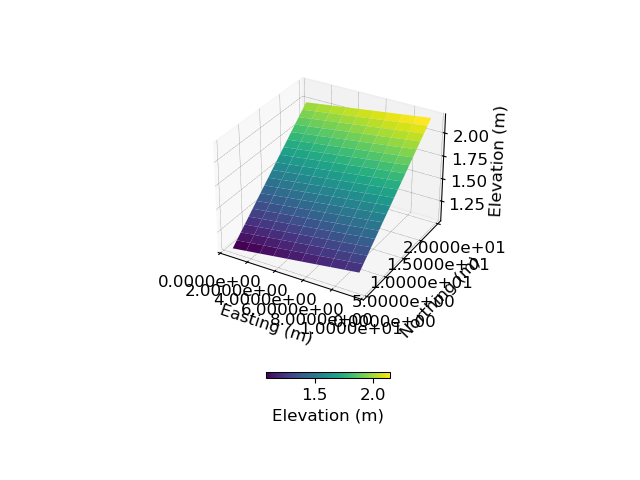

In [8]:
# 🔬 Step 2b — Pass the V-shaped DEM to pyCATHY
simu.update_prepo_inputs(
    DEM     = DEM,
    delta_x = dx,
    delta_y = dy,
    #ivert   = 1,       # vertical extrusion direction
)

# View the DEM as loaded by pyCATHY
simu.show_input(prop='dem')

In [15]:
simu.run_preprocessor(verbose=True)

🍳 gfortran compilation

👟 Run preprocessor

wbb...

 searching the dtm_13.val input file...
 assigned nodata value =  -9999.0000000000000     

 number of processed cells =         200

 ...wbb completed

 rn...
 csort I...
 ...completed

 depit...
 dem modifications =            0
 dem modifications =            0 (total)
 ...completed

 csort II...
 ...completed

 cca...

 contour curvature threshold value =    9.99999996E+11
 ...completed

 smean...
 mean (min,max) facet slope =  0.051952924 ( 0.020000000, 0.053851648)
 ...completed

 dsf...
 the drainage direction of the outlet cell (           4 ) is used
 ...completed

 hg...
 ...completed

 saving the data in the basin_b/basin_i files...

 ...rn completed

 mrbb...


 Select the header type:
 0) None
 1) ESRI ascii file
 2) GRASS ascii file
 (Ctrl C to exit)

 -> 
 Select the nodata value:
 (Ctrl C to exit)

 -> 
 Select the pointer system:
 1) HAP system
 2) Arc/Gis system
 (Ctrl C to exit)

 ->  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dem file

 min value = 0.105000E+01
 max value = 0.218000E+01
 number of cells =   200
 mean value = 0.161500E+01

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 lakes_map file

 min value =     0
 max value =     0
 number of cells =   200
 mean value =     0.000000

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 zone file

 min value =     1
 max value =     1
 number of cells =   200
 mean value =     1.000000

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_w_1 file

 min value = 0.515524E+00
 max value = 0.100000E+01
 number of cells =   200
 mean value = 0.651177E+00

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_w_2 file

 min value = 0.000000E+00
 max value = 0.484476E+00
 number of cells =   200
 mean value = 0.348823E+00

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_p_outflow_1 file

 min value =     2
 max value =     4
 number of cells =   200
 mean value =     3.910000

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_p_outflow_2 file

 min value =     0
 max value =     7
 number of cells =   200
 mean value =     1.655000

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 A_inflow file

 min value = 0.000000000000E+00
 max value = 0.198999970874E+03
 number of cells =   200
 mean value = 0.116326322556E+02

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_local_slope_1 file

 min value = 0.200000E-01
 max value = 0.500000E-01
 number of cells =   200
 mean value = 0.486500E-01

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_local_slope_2 file

 min value = 0.000000E+00
 max value = 0.494975E-01
 number of cells =   200
 mean value = 0.356382E-01

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_epl_1 file

 min value = 0.100000E+01
 max value = 0.100000E+01
 number of cells =   200
 mean value = 0.100000E+01

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_epl_2 file

 min value = 0.000000E+00
 max value = 0.141421E+01
 number of cells =   200
 mean value = 0.101823E+01

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_kSs1_sf_1 file

 min value = 0.240040E+02
 max value = 0.240040E+02
 number of cells =   200
 mean value = 0.240040E+02

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_kSs1_sf_2 file

 min value = 0.000000E+00
 max value = 0.240040E+02
 number of cells =   200
 mean value = 0.172829E+02

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_Ws1_sf file

 min value = 0.100000E+01
 max value = 0.100000E+01
 number of cells =   200
 mean value = 0.100000E+01

 writing the output file...

 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 dtm_Ws1_sf_2 file

 min value = 0.000000E+00
 max value = 0.100000E+01
 number of cells =   200
 mean value

Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG IEEE_DENORMAL

In [16]:
# 🔬 Step 2c — Soil properties
#
# Single homogeneous soil zone, 15 vertical layers.
# Van Genuchten parameters typical of a sandy loam.

df_SPP = simu.init_soil_SPP_map_df(nzones=1, nstr=15)
SPP    = simu.set_SOIL_defaults(SPP_map_default=True)

# Override key parameters
SPP['PERMX'] = 1.0e-5    # Ks = 1×10⁻⁵ m/s  (isotropic)
SPP['PERMY'] = 1.0e-5
SPP['PERMZ'] = 1.0e-5
SPP['VGRMCA'] = 3.6      # α = 3.6 m⁻¹  (loam)
SPP['VGRN']   = 1.56     # n = 1.56
SPP['VGRMC']  = 0.078    # Swr = 0.078

simu.update_soil(PMIN=-5.0, SPP_map=SPP)

# Vegetation / root map (single uniform zone, no roots for simplicity)
simu.update_veg_map()
df_FP = simu.init_soil_FP_map_df(nveg=1)
df_FP = simu.set_SOIL_defaults(FP_map_default=True)
df_FP['ZROOT'] = 0.3     # root depth 0.3 m

print('✓ Soil parameters set')
print(SPP[['PERMX','VGRMCA','VGRN','VGRMC']].to_string())

🔄 Update soil

homogeneous soil

✓ Soil parameters set
            PERMX  VGRMCA  VGRN  VGRMC
zone str                              
1    1    0.00001     3.6  1.56  0.078
     2    0.00001     3.6  1.56  0.078
     3    0.00001     3.6  1.56  0.078
     4    0.00001     3.6  1.56  0.078
     5    0.00001     3.6  1.56  0.078
     6    0.00001     3.6  1.56  0.078
     7    0.00001     3.6  1.56  0.078
     8    0.00001     3.6  1.56  0.078
     9    0.00001     3.6  1.56  0.078
     10   0.00001     3.6  1.56  0.078
     11   0.00001     3.6  1.56  0.078
     12   0.00001     3.6  1.56  0.078
     13   0.00001     3.6  1.56  0.078
     14   0.00001     3.6  1.56  0.078
     15   0.00001     3.6  1.56  0.078


In [17]:
# 🔬 Step 2d — Initial conditions
#
# Start with a uniform negative pressure head (unsaturated, moderately dry).
# ψ = −1 m means the soil is at about 60–70 % saturation for a loam.

simu.update_ic(
    INDP              = 0,     # uniform initial condition
    IPOND             = 0,     # no initial surface ponding
    pressure_head_ini = -1.0   # ψ₀ = −1 m everywhere
)
print('✓ Initial conditions: ψ₀ = −1 m (moderately unsaturated)')

🔄 Update ic

🍳 gfortran compilation

👟 Run preprocessor

🔄 Update parm file 

🛠  Recompile src files [329s]

...

✅ Compilation successful!

👟 Run processor

🔄 Update parm file 

🛠  Recompile src files [344s]

KeyboardInterrupt: 

🔄 Update atmbc

🔄 Update parm file 

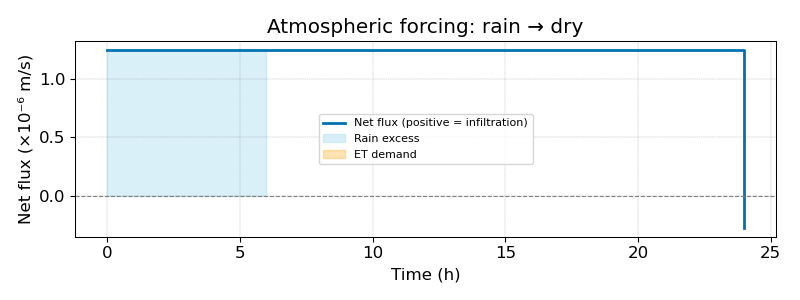

In [11]:
# 🔬 Step 2e — Atmospheric boundary conditions
#
# Synthetic forcing: 6 hours of rain, then 18 hours dry.
# Rain rate: 5 mm/h = 1.39×10⁻⁶ m/s
# ETp during rain: ~0.5 mm/h  → net = +1.39e-6 − 0.14e-6 ≈ +1.25e-6 m/s
# ETp during dry:  ~1 mm/h    → net = 0 − 0.28e-6 ≈ −2.78e-7 m/s

dt_rain = 6   * 3600   # 6 h in seconds
dt_dry  = 18  * 3600   # 18 h in seconds
t_total = dt_rain + dt_dry

rain_rate = 1.39e-6    # m/s  (~5 mm/h)
etp_rain  = 0.14e-6    # m/s  (~0.5 mm/h potential ET)
etp_dry   = 2.78e-7    # m/s  (~1 mm/h potential ET)

# Time breakpoints and net fluxes
t_atmbc    = [0, dt_rain, t_total]
net_values = [rain_rate - etp_rain,   # during rain: net positive (infiltration)
              rain_rate - etp_rain,   # repeated at dt_rain (step function)
              -etp_dry]               # during dry: net negative (ET demand)

simu.update_atmbc(
    HSPATM   = 1,          # uniform spatial forcing
    IETO     = 1,          # ET partitioning enabled
    time     = t_atmbc,
    netValue = net_values
)

# Quick visual check
fig, ax = plt.subplots(figsize=(8, 3))
t_h = np.array(t_atmbc) / 3600
ax.step(t_h, [v * 1e6 for v in net_values], where='post',
        lw=2, color='#0072B2', label='Net flux (positive = infiltration)')
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.fill_between(t_h, [v * 1e6 for v in net_values], 0,
                where=[v > 0 for v in net_values],
                alpha=0.3, color='skyblue', label='Rain excess')
ax.fill_between(t_h, [v * 1e6 for v in net_values], 0,
                where=[v < 0 for v in net_values],
                alpha=0.3, color='orange', label='ET demand')
ax.set_xlabel('Time (h)'); ax.set_ylabel('Net flux (×10⁻⁶ m/s)')
ax.set_title('Atmospheric forcing: rain → dry')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

In [12]:
# 🔬 Step 2f — Solver & output settings

simu.update_parm(
    IPRT     = 4,             # full output including ET partition
    VTKF     = 0,             # skip VTK (faster)
    TIMPRTi  = t_atmbc        # write output at each forcing time step
)

# Boundary conditions: no-flow on all lateral and bottom faces
simu.update_nansfneubc(no_flow=True)
simu.update_nansfdirbc(no_flow=True)
simu.update_sfbc(no_flow=True)

print('✓ Solver settings configured')

🔄 Update parm file 

─────────────────────────────────────────── ⚠ warning messages above ⚠ ────────────────────────────────────────────

['Adjusting NPRT with respect to time of interests requested\n']

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

grid3d missing - need to run the processor with IPRT1=3 first

KeyError: 'mesh3d_nodes'

In [ ]:
# 🔬 Step 3 — Run preprocessor (mesh generation)
#
# This extracts the drainage network from the DEM and creates the 3D mesh.
# For a 10×20 surface grid this takes a few seconds.

simu.run_preprocessor(verbose=False)

# Inspect the 3D mesh
grid3d = simu.read_outputs('grid3d')
print(f'Mesh: {grid3d["nnod"]} nodes, {grid3d["nel"]} elements')

# 3D DEM view
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(7, 5))
ax3 = plt.axes(projection='3d')
simu.show_input(prop='dem', ax=ax3)

In [ ]:
# 🔬 Step 4 — Run processor (PDE solver)
#
# DTMIN / DTMAX control adaptive time stepping.
# For a 24-hour simulation with hourly forcing, these are reasonable defaults.
#
# ⏱  Expected runtime: 1–3 min for this small domain.

simu.run_processor(
    IPRT1   = 2,       # stdout verbosity during run
    DTMIN   = 1e-2,    # min time step: 0.01 s
    DTMAX   = 1e3,     # max time step: ~17 min
    DELTAT  = 1e2,     # initial time step: 100 s
    TRAFLAG = 0,       # Picard iteration
    verbose = True
)
print('✓ Simulation complete')

---
<a id='12'></a>
## 12 · Reading and visualising outputs

After the processor finishes, all results are stored in binary/ASCII files inside `simu.workdir`.  
pyCATHY reads them with `simu.read_outputs(key)` → returns a `pandas.DataFrame`.

In [ ]:
# 🔬 Read pressure head and saturation
from pyCATHY import cathy_utils

df_psi   = simu.read_outputs('psi')   # shape: (n_times, n_nodes)
df_sw, _ = simu.read_outputs('sw')    # shape: (n_times, n_nodes)

# Convert integer time index to actual hours
times_h = df_psi.index / 3600

print(f'ψ output shape : {df_psi.shape}  (time steps × nodes)')
print(f'Time steps (h) : {times_h.values}')

In [ ]:
# 🔬 Find nodes at two locations: upslope and near the outlet

# Surface node at upslope centre
_, up_2d   = simu.find_nearest_node([5.0, 15.0])
up_surf_n, up_surf_p = simu.find_nearest_node([5.0, 15.0, up_2d[0][2] - 0.1])
up_deep_n, up_deep_p = simu.find_nearest_node([5.0, 15.0, up_2d[0][2] - 0.5])

# Surface node near the outlet
_, dn_2d   = simu.find_nearest_node([5.0, 2.0])
dn_surf_n, dn_surf_p = simu.find_nearest_node([5.0, 2.0, dn_2d[0][2] - 0.1])
dn_deep_n, dn_deep_p = simu.find_nearest_node([5.0, 2.0, dn_2d[0][2] - 0.5])

print(f'Upslope surface node : {up_surf_n}  @ {tuple(np.round(up_surf_p[0],2))}')
print(f'Outlet  surface node : {dn_surf_n}  @ {tuple(np.round(dn_surf_p[0],2))}')

In [ ]:
# 🔬 Plot pressure head and saturation time series

COLORS = {
    'up_surf':  '#0072B2',
    'up_deep':  '#56B4E9',
    'dn_surf':  '#D55E00',
    'dn_deep':  '#E69F00',
}

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True,
                          gridspec_kw={'height_ratios': [1, 2, 2]})

# ── Forcing ──────────────────────────────────────────────────────────────────
ax0 = axes[0]
t_seg = np.array([0, dt_rain/3600, dt_rain/3600, t_total/3600])
q_seg = np.array([net_values[0]*1e6, net_values[1]*1e6,
                  net_values[2]*1e6, net_values[2]*1e6])
ax0.fill_between(t_seg, q_seg, 0, where=q_seg>=0,
                  alpha=0.5, color='skyblue', label='Rain excess')
ax0.fill_between(t_seg, q_seg, 0, where=q_seg<=0,
                  alpha=0.5, color='orange', label='ET demand')
ax0.axhline(0, color='grey', lw=0.8)
ax0.set_ylabel('Net flux\n(×10⁻⁶ m/s)')
ax0.legend(fontsize=8, loc='upper right')
ax0.set_title('Forcing', fontsize=10, fontweight='bold')
ax0.grid(True, linestyle='--', alpha=0.4)

# ── Pressure head ─────────────────────────────────────────────────────────────
ax1 = axes[1]
ax1.plot(times_h, df_psi[up_surf_n], label='Upslope surf',
          color=COLORS['up_surf'], marker='+', linestyle='-')
ax1.plot(times_h, df_psi[up_deep_n], label='Upslope −0.5 m',
          color=COLORS['up_deep'], linestyle='--')
ax1.plot(times_h, df_psi[dn_surf_n], label='Outlet surf',
          color=COLORS['dn_surf'], marker='o', linestyle='-', markersize=4)
ax1.plot(times_h, df_psi[dn_deep_n], label='Outlet −0.5 m',
          color=COLORS['dn_deep'], linestyle='--')
ax1.axhline(0, color='grey', lw=0.8, linestyle=':')
ax1.set_ylabel('Pressure head ψ (m)')
ax1.set_title('Pressure Head (ψ < 0: unsaturated, ψ = 0: water table, ψ > 0: saturated)',
               fontsize=9, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.4)

# ── Soil water saturation ─────────────────────────────────────────────────────
ax2 = axes[2]
ax2.plot(times_h, df_sw[up_surf_n], label='Upslope surf',
          color=COLORS['up_surf'], marker='+', linestyle='-')
ax2.plot(times_h, df_sw[up_deep_n], label='Upslope −0.5 m',
          color=COLORS['up_deep'], linestyle='--')
ax2.plot(times_h, df_sw[dn_surf_n], label='Outlet surf',
          color=COLORS['dn_surf'], marker='o', linestyle='-', markersize=4)
ax2.plot(times_h, df_sw[dn_deep_n], label='Outlet −0.5 m',
          color=COLORS['dn_deep'], linestyle='--')
ax2.axhline(1.0, color='grey', lw=0.8, linestyle=':')
ax2.set_ylabel('Degree of saturation sw (−)')
ax2.set_xlabel('Time (h)')
ax2.set_title('Soil Water Content', fontsize=10, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.4)

# Shade the rain period
for ax in axes:
    ax.axvspan(0, dt_rain/3600, alpha=0.05, color='blue', label='_rain')

fig.suptitle('Weill hillslope — pyCATHY simulation results', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 🔬 Read and plot actual ET
df_ET = simu.read_outputs('ET')

# Spatial mean of actual ET
ET_mean = df_ET.groupby('time')['ACT. ETRA'].mean() * 1e3 * 86400  # m/s → mm/day

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(ET_mean.index / 3600, ET_mean.values, width=0.4,
        color='#009E73', label='ETa mean (spatial avg)')
ax.set_xlabel('Time (h)')
ax.set_ylabel('ETa (mm/day)')
ax.set_title('Actual Evapotranspiration — spatial mean over the catchment')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# The ratio ETa/ETp indicates water stress: 1 = no stress, <1 = soil too dry to meet demand
etp_mean_mmday = etp_dry * 1e3 * 86400
print(f'\nPotential ET (dry period)  : {etp_mean_mmday:.1f} mm/day')
print(f'Actual    ET (final step)  : {ET_mean.iloc[-1]:.1f} mm/day')
print(f'ETa/ETp ratio              : {ET_mean.iloc[-1]/etp_mean_mmday:.2f}')

In [ ]:
# 🔬 Interactive: explore a different node position
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Layout, HTML
from IPython.display import display, clear_output

w_x = widgets.BoundedFloatText(value=5.0, min=0.5, max=9.5, step=0.5,
                                description='X (m):', layout=Layout(width='170px'))
w_y = widgets.BoundedFloatText(value=10.0, min=0.5, max=19.5, step=0.5,
                                description='Y (m):', layout=Layout(width='170px'))
w_z = widgets.BoundedFloatText(value=0.1, min=0.05, max=1.0, step=0.05,
                                description='depth (m):', layout=Layout(width='180px'))
out = widgets.Output()

def plot_node(_=None):
    _, pos2d = simu.find_nearest_node([w_x.value, w_y.value])
    node, pos = simu.find_nearest_node([w_x.value, w_y.value, pos2d[0][2] - w_z.value])
    with out:
        clear_output(wait=True)
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.5))
        a1.plot(times_h, df_psi[node], lw=2, color='#0072B2')
        a1.axhline(0, color='grey', lw=0.8, linestyle=':')
        a1.set_xlabel('Time (h)'); a1.set_ylabel('ψ (m)')
        a1.set_title(f'Pressure head  node={node}  pos={tuple(np.round(pos[0],1))}')
        a1.grid(True, linestyle='--', alpha=0.4)

        a2.plot(times_h, df_sw[node], lw=2, color='#D55E00')
        a2.set_xlabel('Time (h)'); a2.set_ylabel('sw (−)')
        a2.set_ylim(0, 1.05)
        a2.set_title(f'Saturation  node={node}')
        a2.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout(); plt.show()

for w in [w_x, w_y, w_z]:
    w.observe(plot_node, names='value')

display(VBox([
    HTML('<b>💡 Explore any node — drag sliders to change location and depth</b>'),
    HBox([w_x, w_y, w_z]),
    out
]))
plot_node()

---
## Summary

| Concept | Key equation | pyCATHY handle |
|---|---|---|
| Water balance | $\Delta S = P - ET - Q - D$ | Global diagnostic from outputs |
| Subsurface flow | Richards equation ($\psi$-based) | `read_outputs('psi')`, `read_outputs('sw')` |
| Surface flow | Diffusion-wave equation | `read_outputs('hgraph')` |
| Coupling | BC switching at land surface | Automatic inside the processor |
| Soil properties | van Genuchten $K_r(\psi)$, $S_w(\psi)$ | `update_soil()` |
| Forcing | Net flux: rain − ETp | `update_atmbc()` |
| Actual ET | $ET_a \leq ET_p$ (stress factor) | `read_outputs('ET')` |
| Solver | FEM (3D) + FD (surface) + adaptive Δt | `update_parm()`, `run_processor()` |

---

### Further reading

- **pyCATHY documentation**: https://benjmy.github.io/pycathy_wrapper/
- **CATHY gallery**: https://benjmy.github.io/pycathy_wrapper/content/SSHydro/index.html
- **Camporese et al. (2010)**: *Surface-subsurface flow modeling with path-based runoff routing…* WRR https://doi.org/10.1029/2008WR007536
- **van Genuchten (1980)**: *A closed-form equation for predicting the hydraulic conductivity of unsaturated soils*, SSSAJ
- **Weill et al. (2009)**: *A generalized Richards equation for surface/subsurface flow modelling*, J. Hydrol.